In [1]:
%load_ext tensorboard
import polars as pl
import seaborn as sns

In [8]:
%tensorboard --logdir /Users/morton/PycharmProjects/Summaries/2026-03-12/run39/train

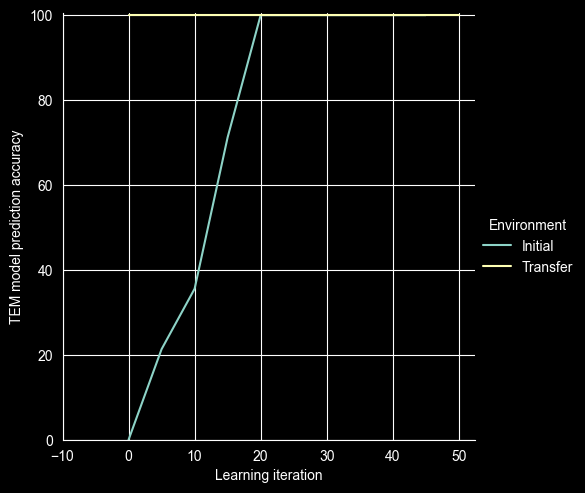

In [6]:
df = pl.read_csv("~/Downloads/csv.csv")
init = 0
tran = 50
offset = 101
early = df.filter(
    pl.col("Step").is_between(init, init + offset) | pl.col("Step").is_between(tran, tran + offset)
).with_columns(
    Lag=pl.when(pl.col("Step") < tran).then(pl.col("Step")).otherwise(pl.col("Step") - tran),
    Environment=pl.when(pl.col("Step") < tran).then(pl.lit("Initial")).otherwise(pl.lit("Transfer")),
)
(
    sns.relplot(early, x="Lag", y="Value", hue="Environment", kind="line")
    .set_axis_labels("Learning iteration", "TEM model prediction accuracy")
    .set(ylim=(0, 100.5), xlim=(-10, None))
    .savefig("training_transfer.pdf")
)